In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Carga de la tabla drivers

drivers = pd.read_csv(
    "../data/drivers.csv",
    sep=",",
    thousands=None,
    decimal=".",
)
drivers.head()

,driverId,name,ssn,location,certified,wage-plan
0,10,George Vetticaden,621011971,244-4532 Nulla Rd.,N,miles
1,11,Jamie Engesser,262112338,366-4125 Ac Street,N,miles
2,12,Paul Coddin,198041975,Ap #622-957 Risus. Street,Y,hours
3,13,Joe Niemiec,139907145,2071 Hendrerit. Ave,Y,hours
4,14,Adis Cesir,820812209,Ap #810-1228 In St.,Y,hours


In [3]:
# Carga de la tabla timesheet
timesheet = pd.read_csv(
    "../data/timesheet.csv",
    sep=",",
    thousands=None,
    decimal=".",
)
timesheet.head()

,driverId,week,hours-logged,miles-logged
0,10,1,70,3300
1,10,2,70,3300
2,10,3,60,2800
3,10,4,70,3100
4,10,5,70,3200


In [4]:
summary = (
    timesheet
    .groupby("driverId", as_index=False)
    .agg(
        hours_logged=("hours-logged", "sum"),
        miles_logged=("miles-logged", "sum")
    )
    .merge(
        drivers[["driverId", "name"]],
        on="driverId",
        how="inner"
    )
    .rename(columns={"driverId": "driver_id"})
)

summary = summary[
    ["driver_id", "hours_logged", "miles_logged", "name"]
]

summary.head()

,driver_id,hours_logged,miles_logged,name
0,10,3232,147150,George Vetticaden
1,11,3642,179300,Jamie Engesser
2,12,2639,135962,Paul Coddin
3,13,2727,134126,Joe Niemiec
4,14,2781,136624,Adis Cesir


In [5]:
# Almacenamiento de los resultados

summary.to_csv(
    "../submission/summary.csv",
    sep=",",
    header=True,
    index=False,
)

In [6]:
print(summary.columns)

Index(['driver_id', 'hours_logged', 'miles_logged', 'name'], dtype='str')


In [7]:
#  Obtener los 10 conductores con más millas
top10 = summary.sort_values(by="miles_logged", ascending=False).head(10)
print(top10)

    driver_id  hours_logged  miles_logged                 name
1          11          3642        179300       Jamie Engesser
0          10          3232        147150    George Vetticaden
23         33          2759        139285    Sridhara Sabbella
15         25          2723        139180  Jean-Philippe Playe
29         39          2745        138788         David Kaiser
5          15          2734        138750         Rohit Bakshi
25         35          2728        138727          Emil Siemes
11         21          2751        138719         Jeff Markham
31         41          2723        138407        Greg Phillips
19         29          2760        138255           Teddy Choi


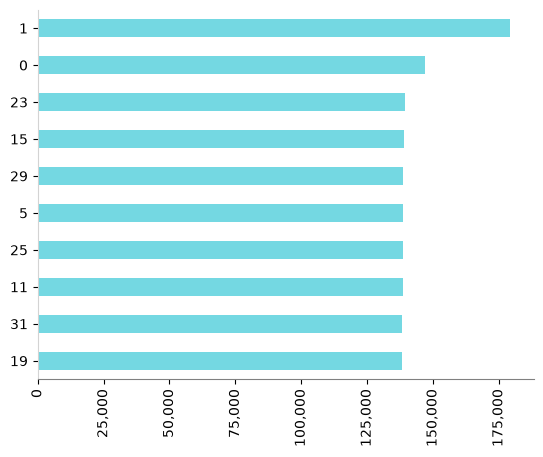

In [8]:
top10["miles_logged"].plot.barh(color="tab:cyan", alpha=0.6)

plt.gca().invert_yaxis()

plt.gca().get_xaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ","))
)

plt.xticks(rotation=90)

plt.gca().spines["left"].set_color("lightgray")
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig("../submission/top10_drivers.png", bbox_inches="tight")